In [ ]:
# ================================
# Install dependencies
# ================================
!pip install sentence-transformers seaborn matplotlib

In [ ]:
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import torch
# ================================
# Step 1: Create 10 sentences across 3 topics
# ================================
# 10 Sentences across 3 distinct topics (Cricket, Cooking, Cybersecurity)
sentences = [
    # Topic 1: Cricket
    "The batsman scored a brilliant century in the final match of the tournament.",
    "A fast yorker completely shattered the stumps before the batter could react.",
    "The spin bowler turned the ball sharply on the dusty pitch.",
    "Fielding restrictions in the first ten overs allowed them to hit multiple boundaries.",

    # Topic 2: Cooking
    "Slow roasting the garlic in olive oil brings out a incredibly sweet, mellow flavor.",
    "Whisk the egg whites vigorously until stiff peaks begin to form.",
    "Deglaze the hot pan with a splash of red wine to create a rich, savory sauce.",

    # Topic 3: Cybersecurity
    "The updated firewall successfully blocked the massive distributed denial of service attack.",
    "Phishing emails often use a false sense of urgency to trick users into clicking malicious links.",
    "End-to-end encryption ensures that only the communicating users can actually read the messages."
]

print("Sentences loaded successfully.")

Sentences loaded successfully.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

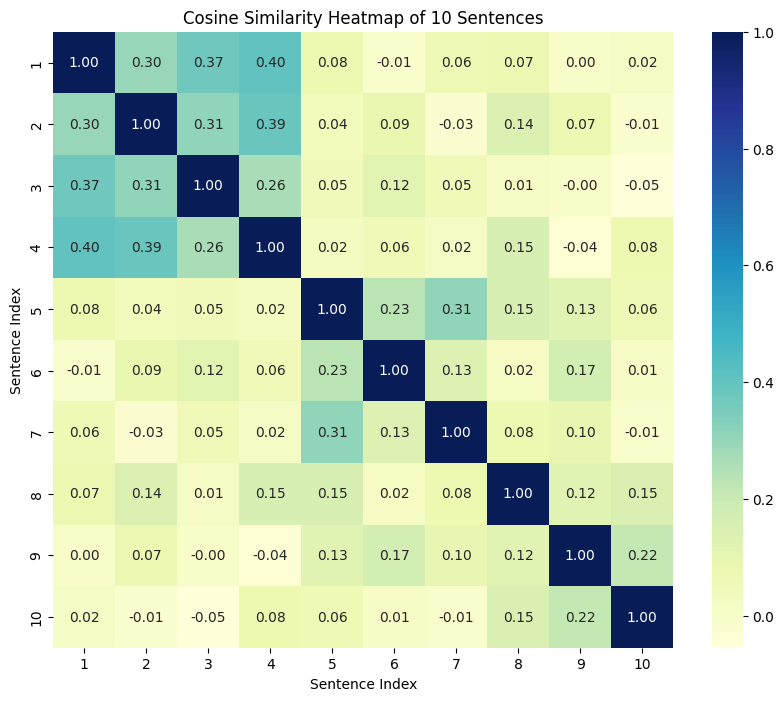

In [ ]:
# Load the pre-trained model specified in the assignment
# ================================
# Step 2: Generate embeddings
# ================================
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate the embeddings for our 10 sentences
embeddings = model.encode(sentences)

# Compute the 10x10 cosine similarity matrix
cosine_scores = util.cos_sim(embeddings, embeddings)

# ================================
# Step 3: Compute and display 10x10 cosine similarity heatmap
# ================================
# Plotting the heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores.numpy(), annot=True, cmap="YlGnBu", fmt=".2f",
            xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.title("Cosine Similarity Heatmap of 10 Sentences")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")
plt.show()

In [ ]:
# ================================
# Step 4: Semantic search for query
# ================================
# The specific query sentence from the assignment
query = "The bowler took three wickets in one over"

# Generate the embedding for the query
query_embedding = model.encode(query)

# Calculate similarity between the query and all 10 sentences
query_scores = util.cos_sim(query_embedding, embeddings)[0]

# Find the top 2 most similar sentences
top_results = torch.topk(query_scores, k=2)

print(f"Query: '{query}'\n")
print("Top 2 Most Similar Sentences:")
print("-" * 50)

for score, idx in zip(top_results[0], top_results[1]):
    print(f"Score: {score:.4f}")
    print(f"Sentence: {sentences[idx]}\n")

Query: 'The bowler took three wickets in one over'

Top 2 Most Similar Sentences:
--------------------------------------------------
Score: 0.5809
Sentence: The spin bowler turned the ball sharply on the dusty pitch.

Score: 0.5206
Sentence: The batsman scored a brilliant century in the final match of the tournament.

